<a href="https://colab.research.google.com/github/JaynthReddy91/DL/blob/main/enc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # Compressed representation (changed from 392 to 32)

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded) # Output layer still reconstructs to original input_dim (784)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# The test and visualization steps will be in the next cell to ensure the model is trained with the correct dimensions.

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2179 - val_loss: 0.1561
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1351 - val_loss: 0.1168
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1080 - val_loss: 0.0985
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0944 - val_loss: 0.0887
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0865 - val_loss: 0.0827
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0815 - val_loss: 0.0788
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0782 - val_loss: 0.0761
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0758 - val_loss: 0.0742
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0740 - val_loss: 0.0727
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0726 - val_loss: 0.0715
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0715 - val_loss: 0.0706
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

Training autoencoder with encoding dimension = 1024 (over compression)...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2576 - val_loss: 0.2380
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3151 - val_loss: 0.4327
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5625 - val_loss: 0.7147
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8428 - val_loss: 0.9089
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9540 - val_loss: 1.0444
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1733 - val_loss: 1.2490
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2223 - val_loss: 1.3667
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4056 - val_loss: 1.4444
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5291 - val_loss: 1.6119
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6159 - val_loss: 1.6398
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.64

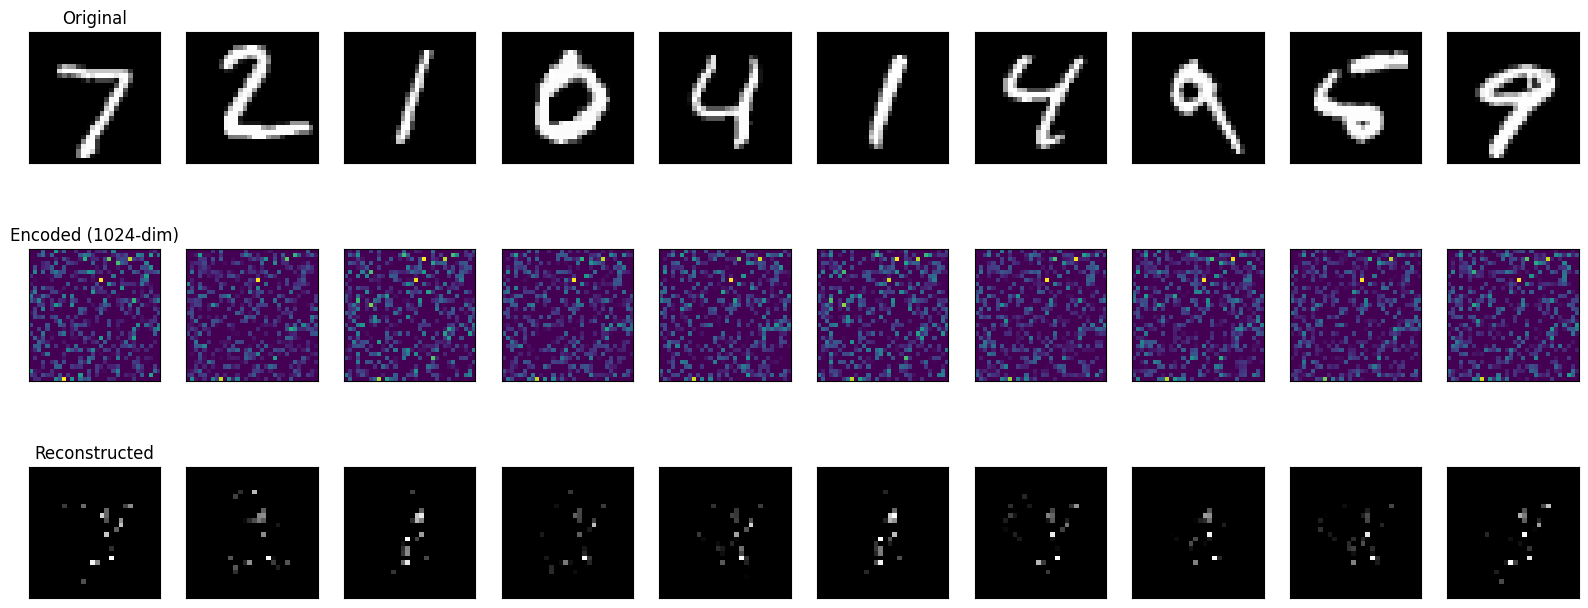

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# Define the encoding dimension to be greater than the input dimension
encoding_dim_over_compression = 1024 # Greater than 784

# Ensure input_dim is still 784 (from previous cells)
# input_dim = 784 # Assuming input_dim is defined in previous cells

# Encoder for over-compression scenario
input_layer_over_comp = Input(shape=(input_dim,))
encoded_over_comp = Dense(encoding_dim_over_compression, activation='relu')(input_layer_over_comp) # Changed to relu

# Decoder for over-compression scenario (reconstructs to original 784 dimensions)
decoded_over_comp = Dense(input_dim, activation='relu')(encoded_over_comp) # Changed to relu

# Create the Autoencoder Model
autoencoder_over_compression = Model(input_layer_over_comp, decoded_over_comp)

# Compile the Model
autoencoder_over_compression.compile(optimizer='adam', loss='binary_crossentropy')

print(f"Training autoencoder with encoding dimension = {encoding_dim_over_compression} (over compression)...")
autoencoder_over_compression.fit(x_train, x_train,
                                 epochs=50,
                                 batch_size=256, shuffle=True,
                                 validation_data=(x_test, x_test))

# Test the Model
decoded_imgs_over_comp = autoencoder_over_compression.predict(x_test)

# Create an encoder model for this autoencoder
encoder_over_compression = Model(input_layer_over_comp, encoded_over_comp)
encoded_imgs_over_comp = encoder_over_compression.predict(x_test)

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 8)) # Adjusted height for 3 rows
for i in range(n):
    # Display original image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original")

    # Display encoded representation (1024-dim, reshaped to 32x32 for visualization)
    ax = plt.subplot(3, n, i + 1 + n) # Second row
    # Reshape 1024 to 32x32 for visualization
    plt.imshow(encoded_imgs_over_comp[i].reshape(32, 32), cmap='viridis')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title(f"Encoded ({encoding_dim_over_compression}-dim)")

    # Display reconstructed image
    ax = plt.subplot(3, n, i + 1 + 2 * n) # Third row
    plt.imshow(decoded_imgs_over_comp[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Reconstructed")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


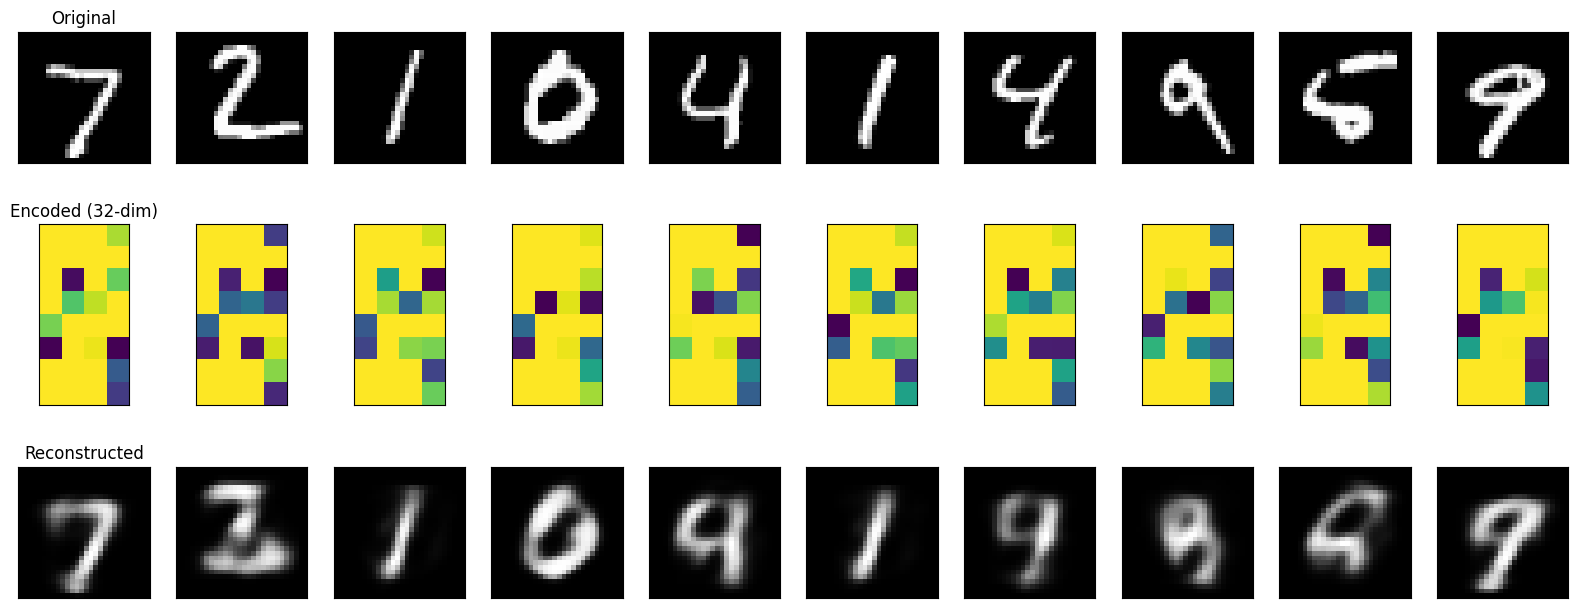

In [2]:
# Create an encoder model to get the compressed representation
encoder = Model(input_layer, encoded)
encoded_imgs = encoder.predict(x_test)

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 8)) # Adjusted height for 3 rows
for i in range(n):
    # Display original image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original")

    # Display encoded representation (compressed pixels)
    ax = plt.subplot(3, n, i + 1 + n) # Second row
    # Reshape the 32-dimensional vector into an 8x4 image for visualization
    plt.imshow(encoded_imgs[i].reshape(8, 4), cmap='viridis') # Using 'viridis' colormap for latent space
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Encoded (32-dim)")

    # Display reconstructed image
    ax = plt.subplot(3, n, i + 1 + 2 * n) # Third row
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Reconstructed")
plt.show()

Training autoencoder with encoding dimension = 750 (slightly less compression)...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2281 - val_loss: 0.1774
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2091 - val_loss: 0.2398
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3271 - val_loss: 0.4576
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5527 - val_loss: 0.5996
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6773 - val_loss: 0.7703
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8248 - val_loss: 0.9254
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9377 - val_loss: 1.0036
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0761 - val_loss: 1.1961
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2953 - val_loss: 1.4453
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5154 - val_loss: 1.5513
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - l

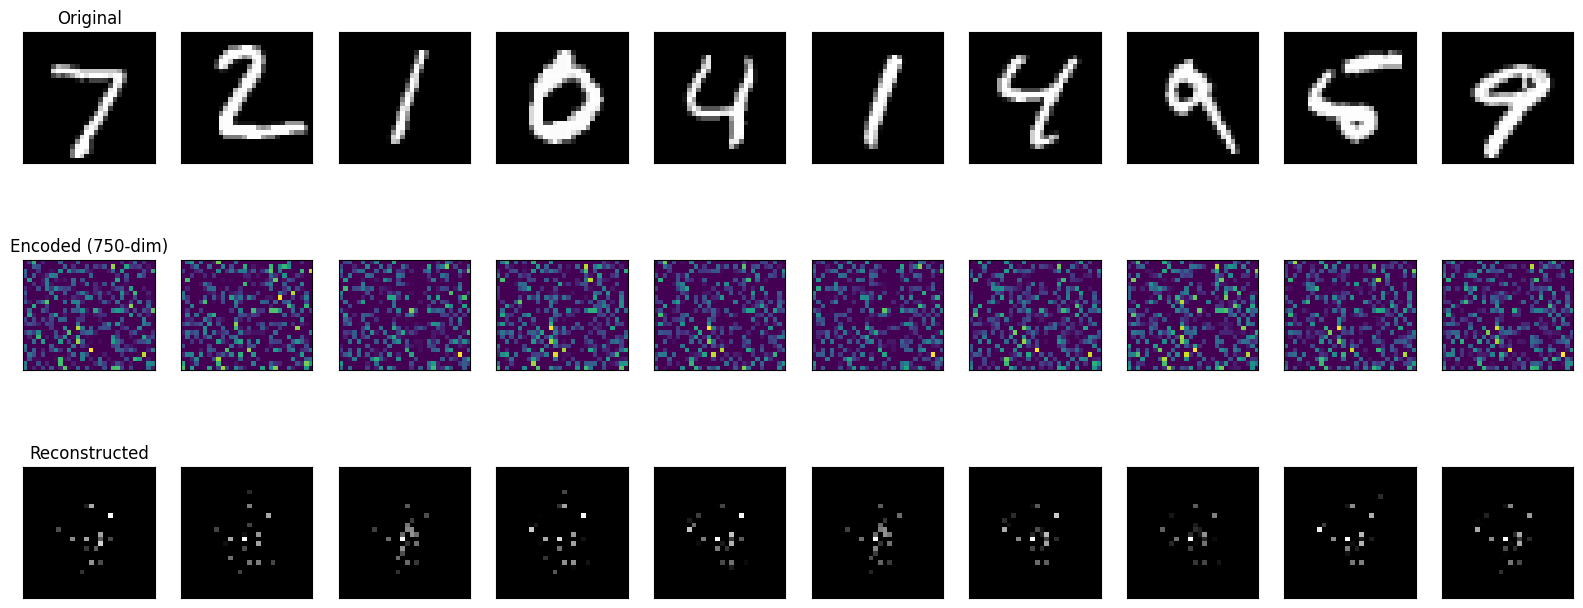

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# Define the encoding dimension to be slightly less than the input dimension
encoding_dim_less_compression = 750 # Between 700 and 780

# Encoder for slightly less compression scenario
input_layer_less_comp = Input(shape=(input_dim,))
encoded_less_comp = Dense(encoding_dim_less_compression, activation='relu')(input_layer_less_comp)

# Decoder for slightly less compression scenario (reconstructs to original 784 dimensions)
decoded_less_comp = Dense(input_dim, activation='relu')(encoded_less_comp)

# Create the Autoencoder Model
autoencoder_less_compression = Model(input_layer_less_comp, decoded_less_comp)

# Compile the Model
autoencoder_less_compression.compile(optimizer='adam', loss='binary_crossentropy')

print(f"Training autoencoder with encoding dimension = {encoding_dim_less_compression} (slightly less compression)...")
autoencoder_less_compression.fit(x_train, x_train,
                                 epochs=50,
                                 batch_size=256, shuffle=True,
                                 validation_data=(x_test, x_test))

# Test the Model
decoded_imgs_less_comp = autoencoder_less_compression.predict(x_test)

# Create an encoder model for this autoencoder
encoder_less_compression = Model(input_layer_less_comp, encoded_less_comp)
encoded_imgs_less_comp = encoder_less_compression.predict(x_test)

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 8)) # Adjusted height for 3 rows
for i in range(n):
    # Display original image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original")

    # Display encoded representation (750-dim). Reshape to 25x30 for visualization.
    ax = plt.subplot(3, n, i + 1 + n) # Second row
    plt.imshow(encoded_imgs_less_comp[i].reshape(25, 30), cmap='viridis') # 25 * 30 = 750
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title(f"Encoded ({encoding_dim_less_compression}-dim)")

    # Display reconstructed image
    ax = plt.subplot(3, n, i + 1 + 2 * n) # Third row
    plt.imshow(decoded_imgs_less_comp[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Reconstructed")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


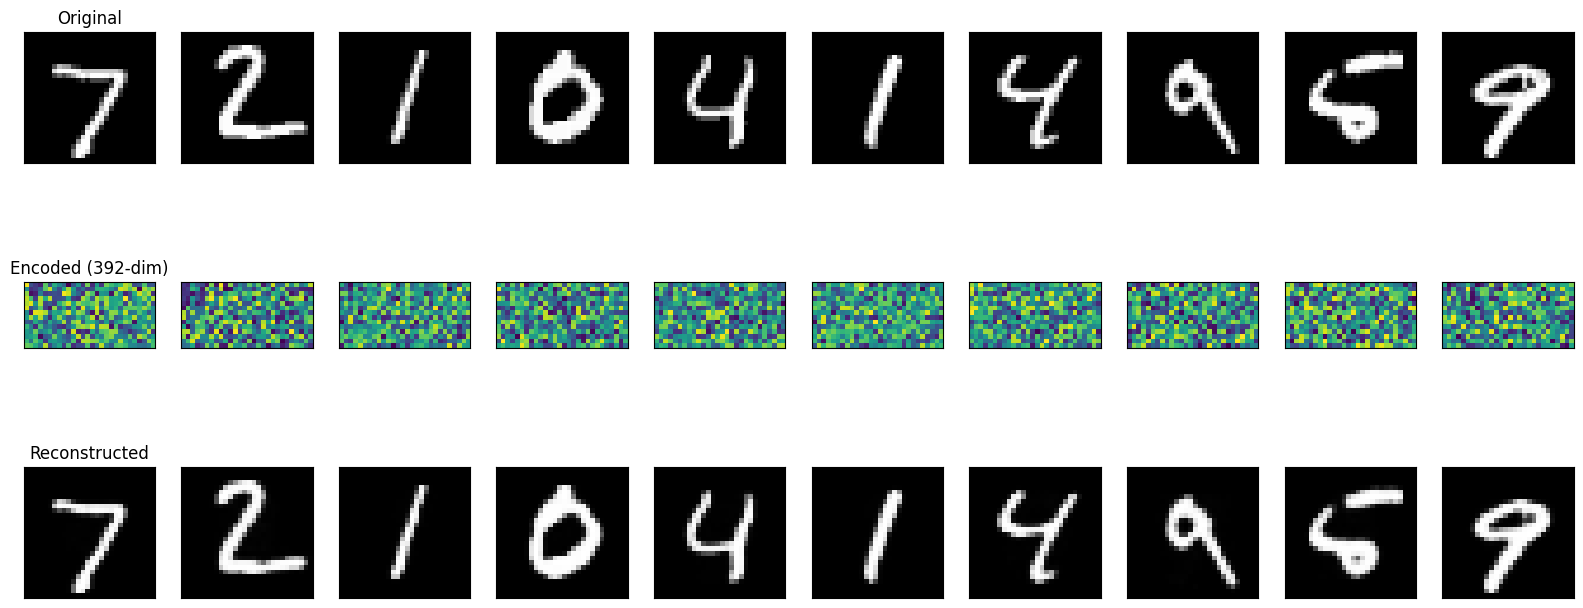

In [6]:
# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# Create an encoder model to get the compressed representation
encoder = Model(input_layer, encoded)
encoded_imgs = encoder.predict(x_test)

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 8)) # Adjusted height for 3 rows
for i in range(n):
    # Display original image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original")

    # Display encoded representation (compressed pixels)
    ax = plt.subplot(3, n, i + 1 + n) # Second row
    # Reshape the 32-dimensional vector into an 8x4 image for visualization (8*4 = 32)
    plt.imshow(encoded_imgs[i].reshape(8, 4), cmap='viridis') # Using 'viridis' colormap for latent space
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Encoded (32-dim)")

    # Display reconstructed image
    ax = plt.subplot(3, n, i + 1 + 2 * n) # Third row
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Reconstructed")
plt.show()

Training autoencoder to reconstruct 64-dimensional output...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0371 - val_loss: 0.0027
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0016 - val_loss: 9.2491e-04
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.7795e-04 - val_loss: 5.2035e-04
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1851e-04 - val_loss: 3.5850e-04
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.0133e-04 - val_loss: 2.7548e-04
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.3701e-04 - val_loss: 2.2655e-04
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9743e-04 - val_loss: 1.9505e-04
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7120e-04 - val_loss: 1.7356e-04
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5292e-04 - val_loss: 1.5826e-04
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3968e-04 - val_loss: 1.4699e-04
Epoch 11/5

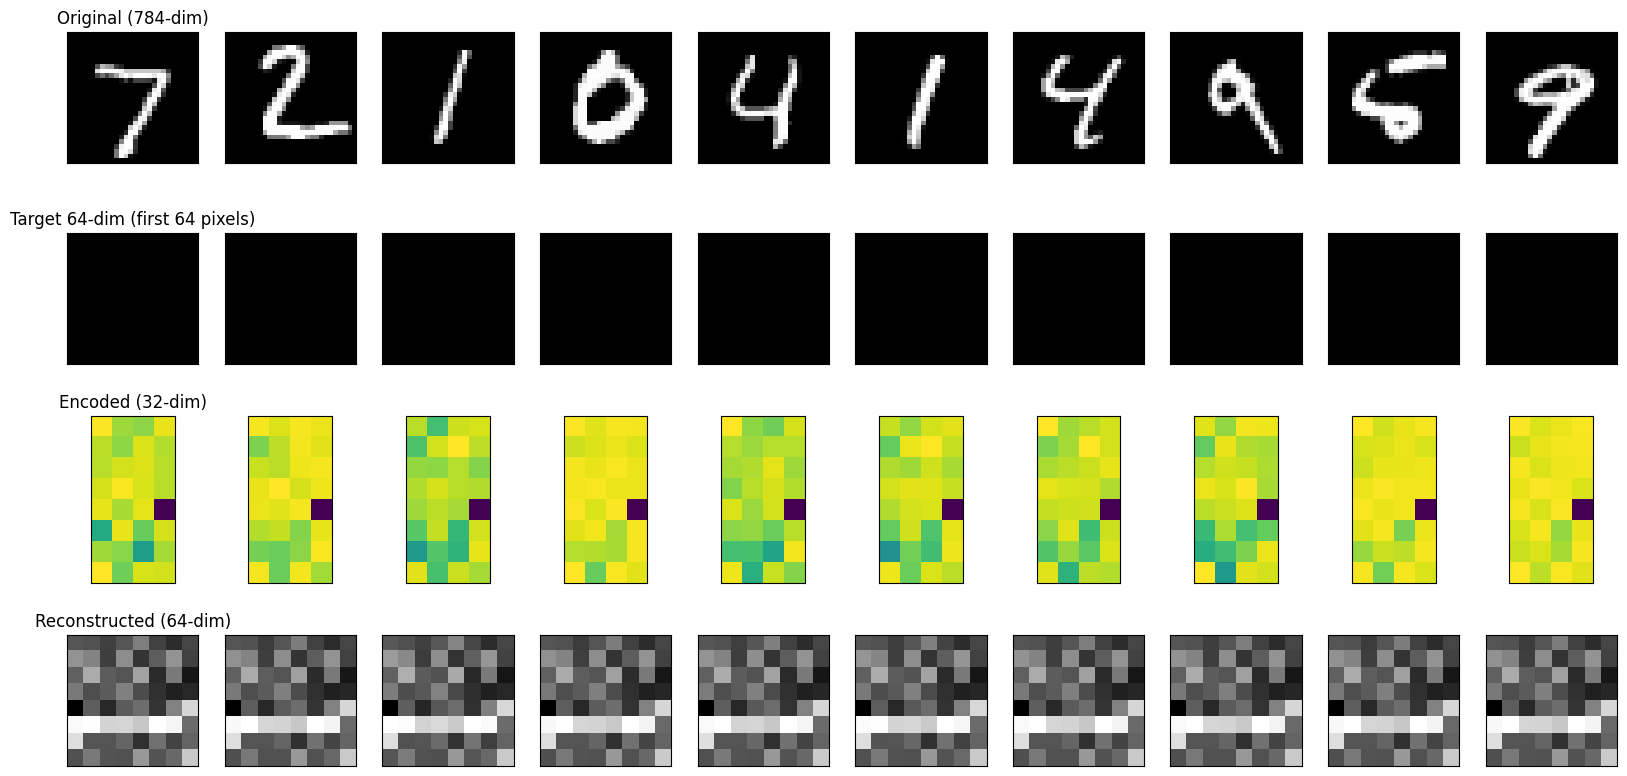

In [8]:
# Define the new reconstruction dimension
reconstruction_dim = 64

# Set the encoding dimension for this specific autoencoder to 32
encoding_dim = 32 # Explicitly setting encoding_dim for this model

# Encoder (reusing input_dim from previous cells)
input_layer_new = Input(shape=(input_dim,))
encoded_new = Dense(encoding_dim, activation='sigmoid')(input_layer_new)

# Decoder, now outputting to reconstruction_dim
decoded_new = Dense(reconstruction_dim, activation='sigmoid')(encoded_new)

# Create the new Autoencoder Model
autoencoder_64_dim_output = Model(input_layer_new, decoded_new)

# Compile the Model
autoencoder_64_dim_output.compile(optimizer='adam', loss='mse') # Using MSE as loss for non-binary output

# Train the Model
# For training, we need to provide a target for the 64-dim output.
# Since we don't have a specific 64-dim target, we'll use a simple approach:
# For demonstration, we'll try to reconstruct the first 64 pixels of the original image.
# In a real-world scenario, you would have a specific 64-dim target dataset.

x_train_64_dim_target = x_train[:, :reconstruction_dim]
x_test_64_dim_target = x_test[:, :reconstruction_dim]

print(f"Training autoencoder to reconstruct {reconstruction_dim}-dimensional output...")
autoencoder_64_dim_output.fit(x_train, x_train_64_dim_target,
                              epochs=50, batch_size=256, shuffle=True,
                              validation_data=(x_test, x_test_64_dim_target))

# Test the new Model
decoded_imgs_64_dim = autoencoder_64_dim_output.predict(x_test)

# Create an encoder model from the new autoencoder
encoder_64_dim_output = Model(input_layer_new, encoded_new)
encoded_imgs_64_dim = encoder_64_dim_output.predict(x_test)

# 7. Visualize Results for 64-dim output
n = 10
plt.figure(figsize=(20, 10)) # Adjusted height for 4 rows
for i in range(n):
    # Display original image
    ax = plt.subplot(4, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original (784-dim)")

    # Display target for 64-dim reconstruction (first 64 pixels)
    ax = plt.subplot(4, n, i + 1 + n) # Second row
    plt.imshow(x_test_64_dim_target[i].reshape(8, 8), cmap='gray') # Reshaping 64 to 8x8 for visualization
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Target 64-dim (first 64 pixels)")

    # Display encoded representation (compressed pixels) - 32-dim
    ax = plt.subplot(4, n, i + 1 + 2 * n) # Third row
    plt.imshow(encoded_imgs_64_dim[i].reshape(8, 4), cmap='viridis') # Using 'viridis' colormap for latent space
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Encoded (32-dim)")

    # Display reconstructed 64-dim image
    ax = plt.subplot(4, n, i + 1 + 3 * n) # Fourth row
    plt.imshow(decoded_imgs_64_dim[i].reshape(8, 8), cmap='gray') # Reshaping 64 to 8x8 for visualization
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Reconstructed (64-dim)")
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error

# Calculate MSE for the original autoencoder (784-dim reconstruction)
mse_original_reconstruction = mean_squared_error(x_test.reshape(-1, input_dim), decoded_imgs.reshape(-1, input_dim))
print(f"MSE for original autoencoder (784-dim reconstruction): {mse_original_reconstruction:.6f}")

# Calculate MSE for the 64-dim output autoencoder
# We compare the reconstructed 64 dimensions against the first 64 dimensions of the original test images
mse_64_dim_reconstruction = mean_squared_error(x_test_64_dim_target.reshape(-1, reconstruction_dim), decoded_imgs_64_dim.reshape(-1, reconstruction_dim))
print(f"MSE for 64-dim output autoencoder (reconstructing first 64 pixels): {mse_64_dim_reconstruction:.6f}")

MSE for original autoencoder (784-dim reconstruction): 0.001187
MSE for 64-dim output autoencoder (reconstructing first 64 pixels): 0.000100


In [ ]:
from sklearn.metrics import mean_squared_error

# Calculate MSE for the original autoencoder (32-dim encoding, 784-dim reconstruction)
mse_32_dim_encoding = mean_squared_error(x_test.reshape(-1, input_dim), decoded_imgs.reshape(-1, input_dim))
print(f"MSE for 32-dim encoding (original autoencoder): {mse_32_dim_encoding:.6f}")

# Calculate MSE for the 'over-compression' autoencoder (1024-dim encoding)
mse_1024_dim_encoding = mean_squared_error(x_test.reshape(-1, input_dim), decoded_imgs_over_comp.reshape(-1, input_dim))
print(f"MSE for 1024-dim encoding (over-compression autoencoder): {mse_1024_dim_encoding:.6f}")

# Calculate MSE for the 'slightly less compression' autoencoder (750-dim encoding)
mse_750_dim_encoding = mean_squared_error(x_test.reshape(-1, input_dim), decoded_imgs_less_comp.reshape(-1, input_dim))
print(f"MSE for 750-dim encoding (slightly less compression autoencoder): {mse_750_dim_encoding:.6f}")

# Determine the best accuracy
min_mse = min(mse_32_dim_encoding, mse_1024_dim_encoding, mse_750_dim_encoding)

if min_mse == mse_32_dim_encoding:
    best_encoding_dim = 32
elif min_mse == mse_1024_dim_encoding:
    best_encoding_dim = 1024
else:
    best_encoding_dim = 750

print(f"\nThe encoding dimension giving the best accuracy (lowest MSE) is: {best_encoding_dim} (MSE: {min_mse:.6f})")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error

# Assuming x_train, x_test, and input_dim are already loaded/defined from previous cells
# (e.g., from mnist.load_data() and x_train.reshape())

performance_results = []

# Define the range and step for encoding dimensions
min_encoding_dim = 1
max_encoding_dim = input_dim  # 784
step_encoding_dim = 25  # Adjust this step to change granularity
epochs_per_model = 10  # Reduced epochs for faster execution

print(f"Evaluating autoencoder performance for encoding dimensions from {min_encoding_dim} to {max_encoding_dim} with a step of {step_encoding_dim} and {epochs_per_model} epochs per model...")

for encoding_dim_iter in range(min_encoding_dim, max_encoding_dim + 1, step_encoding_dim):
    print(f"\nTraining autoencoder with encoding dimension: {encoding_dim_iter}")

    # Encoder
    input_layer_iter = Input(shape=(input_dim,))
    encoded_iter = Dense(encoding_dim_iter, activation='sigmoid')(input_layer_iter)

    # Decoder
    decoded_iter = Dense(input_dim, activation='sigmoid')(encoded_iter)

    # Autoencoder Model
    autoencoder_iter = Model(input_layer_iter, decoded_iter)

    # Compile the Model
    autoencoder_iter.compile(optimizer='adam', loss='binary_crossentropy')

    # Train the Model
    autoencoder_iter.fit(x_train, x_train,
                         epochs=epochs_per_model,
                         batch_size=256, shuffle=True,
                         validation_data=(x_test, x_test),
                         verbose=0) # Set verbose to 0 to suppress training output

    # Test the Model and calculate MSE
    decoded_imgs_iter = autoencoder_iter.predict(x_test, verbose=0)
    mse = mean_squared_error(x_test.reshape(-1, input_dim), decoded_imgs_iter.reshape(-1, input_dim))

    performance_results.append({'encoding_dim': encoding_dim_iter, 'mse': mse})
    print(f"  MSE: {mse:.6f}")


# Plotting the results
encoding_dims = [res['encoding_dim'] for res in performance_results]
mse_values = [res['mse'] for res in performance_results]

plt.figure(figsize=(12, 6))
plt.plot(encoding_dims, mse_values, marker='o', linestyle='-')
plt.title('Autoencoder Reconstruction MSE vs. Encoding Dimension')
plt.xlabel('Encoding Dimension')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.xticks(np.arange(0, max_encoding_dim + 1, step_encoding_dim * 2))
plt.tight_layout()
plt.show()

print("\nPerformance Results:")
for res in performance_results:
    print(f"  Encoding Dimension: {res['encoding_dim']}, MSE: {res['mse']:.6f}")